# Phase 5: Behavioral Model Development

Predicts credit default for **active clients** (those with purchase history) by combining
pre-registration features (Serasa, iFood, CNAE, segment) with aggregated order behaviour
(order frequency, value statistics, payment delays, recency).

**Key question:** do behavioral signals (delay patterns, order cadence, order value) improve
prediction beyond what the Application Model already achieves on this same sub-population?

**Pipeline:**
1. Load Phase 3 behavioral combined features
2. Filter to clients with behavioral data (≥1 order)
3. Parse interval strings; engineer behavioral features
4. Stratified 70/30 train-test split
5. Baseline: application-only model on the same sub-population
6. Logistic Regression, Random Forest, XGBoost (application + behavioral features)
7. Hyperparameter tuning on best model
8. Final evaluation: ROC curve, confusion matrix, feature importance
9. Compare behavioral vs. application-only on the same test split
10. Save best model & metrics

In [1]:
import warnings
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT      = Path('..').resolve()
DATA_DIR  = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print('Root:', ROOT)
print('Data dir:', DATA_DIR)

Root: /Users/esdrasalbino/Documents/university/machine-learning/project_praso
Data dir: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data


## 1. Load Phase 3 Behavioral Combined Features

In [2]:
behav_files = sorted(DATA_DIR.glob('03_behavioral_combined_*.csv'))
if not behav_files:
    raise FileNotFoundError('No Phase 3 behavioral combined file found. Run 01_eda_and_exploration.ipynb first.')

behav_path = behav_files[-1]
print('Loading:', behav_path.name)

df_full = pd.read_csv(behav_path, low_memory=False)
print(f'Full dataset shape: {df_full.shape}')
print(f'Target distribution (full):\n{df_full["inadimplente"].value_counts().to_frame()}')

Loading: 03_behavioral_combined_20260520_205746.csv
Full dataset shape: (3000, 60)
Target distribution (full):
              count
inadimplente       
0.0            2060
1.0             940


## 2. Filter to Clients With Behavioral Data

The behavioral model is only relevant for clients who have at least one order.
Clients without order history are handled by the Application Model (Phase 4).

In [3]:
has_behavioral = df_full['orders_count'].notna()
df_raw = df_full[has_behavioral].copy().reset_index(drop=True)

print(f'Clients WITH behavioral data : {len(df_raw):,}  ({has_behavioral.mean():.1%} of total)')
print(f'Clients WITHOUT behavioral data: {(~has_behavioral).sum():,}  (→ handled by Application Model)')
print(f'\nDefault rate in behavioral subset:')
print(df_raw['inadimplente'].value_counts(normalize=True).round(3))

BEHAVIORAL_COLS = [
    'orders_count', 'valor_min', 'valor_max', 'valor_mean', 'valor_median',
    'valor_std', 'delay_mean', 'delay_max', 'pct_orders_delayed',
    'recency_days', 'orders_per_month',
]

print(f'\nBehavioral feature statistics:')
display(df_raw[BEHAVIORAL_COLS].describe().round(2))

Clients WITH behavioral data : 664  (22.1% of total)
Clients WITHOUT behavioral data: 2,336  (→ handled by Application Model)

Default rate in behavioral subset:
inadimplente
0.0    0.792
1.0    0.208
Name: proportion, dtype: float64

Behavioral feature statistics:


,orders_count,valor_min,valor_max,valor_mean,valor_median,valor_std,delay_mean,delay_max,pct_orders_delayed,recency_days,orders_per_month
count,664.00,664.00,664.00,664.00,664.00,662.00,664.00,664.00,664.00,664.00,664.00
mean,2.98,7823.80,151105.42,60631.28,22964.61,82967.90,30109.29,67770.49,0.73,937.30,3.50
std,0.17,194065.16,855326.02,372650.48,335618.05,482362.46,272961.50,578593.83,0.34,196.98,4.32
min,1.00,250.00,250.00,250.00,250.00,0.00,-50.00,-50.00,0.00,49.00,0.07
25%,3.00,250.00,250.00,250.00,250.00,0.00,-16.00,1.00,0.67,848.75,0.91
50%,3.00,250.00,250.00,250.00,250.00,0.00,1.00,3.00,1.00,960.50,2.43
75%,3.00,250.00,750.00,416.67,250.00,288.68,1.67,5.00,1.00,1058.00,4.29
max,3.00,5001000.00,5001000.00,5001000.00,5001000.00,2887184.36,3333368.33,5000030.00,1.00,1450.00,45.00


## 3. Feature Engineering

Same refinements as Phase 4 (interval parsing, CNAE division, Serasa creditor count) plus
additional behavioral transformations:
- Log-scale order values to reduce skew from outliers
- Binary flag for any payment delay
- Ratio of max delay to mean delay (captures delay spikes)

In [4]:
def parse_interval_midpoint(series):
    def _mid(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip().lstrip('([').rstrip('])')
        parts = [p.strip() for p in s.split(',')]
        try:
            return (float(parts[0]) + float(parts[1])) / 2.0
        except Exception:
            return np.nan
    return series.apply(_mid)


df = df_raw.copy()

# --- Application: interval columns → numeric midpoints ---
for col, new_col in [
    ('capital_social',        'capital_social_mid'),
    ('idade_cnpj',            'idade_cnpj_mid'),
    ('google_maps_avaliacao', 'google_maps_avaliacao_mid'),
]:
    if col in df.columns:
        df[new_col] = parse_interval_midpoint(df[col])
        print(f'{col} → {new_col}  nulls={df[new_col].isna().sum()}')

# --- CNAE: 2-digit division ---
if 'cnae_codigo' in df.columns:
    df['cnae_divisao'] = df['cnae_codigo'].astype(str).str.extract(r'^(\d+)')[0]

# --- Serasa credores: count of sectors ---
if 'serasa_credores' in df.columns:
    df['serasa_n_setores'] = df['serasa_credores'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 0
    )

# --- ifood / google_maps: coerce to numeric ---
for col in ['ifood_contagem_avaliacoes', 'google_maps_contagem_avaliacoes']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Behavioral: derived features ---
# Log-transform order values (heavy right-skew)
for col in ['valor_mean', 'valor_max', 'valor_min', 'valor_median', 'valor_std']:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

# Binary: any delay ever
if 'pct_orders_delayed' in df.columns:
    df['has_any_delay'] = (df['pct_orders_delayed'] > 0).astype(int)

# Delay spike ratio (max delay / mean delay + 1 to avoid div-by-zero)
if 'delay_max' in df.columns and 'delay_mean' in df.columns:
    df['delay_spike_ratio'] = df['delay_max'] / (df['delay_mean'] + 1)

# Cast booleans to int
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)
print(f'\nCast {len(bool_cols)} bool columns to int.')
print(f'Dataset shape after engineering: {df.shape}')

capital_social → capital_social_mid  nulls=0
idade_cnpj → idade_cnpj_mid  nulls=0
google_maps_avaliacao → google_maps_avaliacao_mid  nulls=656

Cast 31 bool columns to int.
Dataset shape after engineering: (664, 72)


## 4. Feature Selection

In [5]:
TARGET = 'inadimplente'

drop_cols = [
    'id_cliente',
    'municipio',
    'cnae_codigo',
    'capital_social',
    'idade_cnpj',
    'google_maps_avaliacao',
    'serasa_credores',
    'idade_cnpj_midpoint',   # all-null from Phase 3 — replaced by idade_cnpj_mid
    'last_order_date',
    'first_order_date',
    TARGET,
]
drop_cols = [c for c in drop_cols if c in df.columns]

# Drop entirely-null columns
all_null = [c for c in df.columns if df[c].isna().all() and c not in drop_cols]
if all_null:
    print('Dropping all-null columns:', all_null)
    drop_cols.extend(all_null)

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].copy()
y = df[TARGET].astype(int)

numeric_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Identify which features are behavioral (for later analysis)
behavioral_feature_names = [
    c for c in feature_cols
    if any(c.startswith(p) for p in [
        'orders_count', 'valor_', 'log_valor', 'delay_', 'pct_orders_delayed',
        'recency_days', 'orders_per_month', 'has_any_delay', 'delay_spike_ratio',
    ])
]

print(f'Total features  : {X.shape[1]}')
print(f'Behavioral feats: {len(behavioral_feature_names)}')
print(f'Application feats: {X.shape[1] - len(behavioral_feature_names)}')
print(f'Samples         : {X.shape[0]}')
print(f'Default rate    : {y.mean():.1%}')
print(f'\nBehavioral features: {behavioral_feature_names}')
print(f'Categorical cols: {categorical_cols}')

Dropping all-null columns: ['ifood_contagem_avaliacoes', 'google_maps_contagem_avaliacoes']
Total features  : 59
Behavioral feats: 18
Application feats: 41
Samples         : 664
Default rate    : 20.8%

Behavioral features: ['orders_count', 'valor_min', 'valor_max', 'valor_mean', 'valor_median', 'valor_std', 'delay_mean', 'delay_max', 'pct_orders_delayed', 'recency_days', 'orders_per_month', 'log_valor_mean', 'log_valor_max', 'log_valor_min', 'log_valor_median', 'log_valor_std', 'has_any_delay', 'delay_spike_ratio']
Categorical cols: ['ifood_faixa_preco', 'cnae_divisao']


## 5. Train-Test Split (70/30 Stratified)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train default rate: {y_train.mean():.1%}  |  Test default rate: {y_test.mean():.1%}')

Train: 464 rows  |  Test: 200 rows
Train default rate: 20.7%  |  Test default rate: 21.0%


## 6. Preprocessing Pipeline

- **Numeric**: median imputation → standard scaling
- **Categorical**: constant imputation → one-hot encoding

In [7]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols),
    ],
    remainder='drop',
)

print('Preprocessor built.')

Preprocessor built.


## 7. Helper: Evaluate a Model

In [8]:
def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    y_pred = pipeline.predict(X_te)
    metrics = {
        'roc_auc':   round(roc_auc_score(y_te, y_prob), 4),
        'accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
        'f1':        round(f1_score(y_te, y_pred, zero_division=0), 4),
    }
    print(f'[{name}]  ROC-AUC={metrics["roc_auc"]:.4f}  F1={metrics["f1"]:.4f}  '
          f'Precision={metrics["precision"]:.4f}  Recall={metrics["recall"]:.4f}')
    return metrics, y_prob

## 8. Baseline: Application-Only Model on Behavioral Sub-population

To measure the **lift** from behavioral features we first train an application-only model
on the same 664-client subset using only the application columns (no order history features).
This is the fair baseline — same data, same split, just fewer features.

In [9]:
app_only_cols = [c for c in feature_cols if c not in behavioral_feature_names]
app_numeric_cols     = [c for c in numeric_cols if c not in behavioral_feature_names]
app_categorical_cols = [c for c in categorical_cols if c not in behavioral_feature_names]

app_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, app_numeric_cols),
        ('cat', categorical_pipe, app_categorical_cols),
    ],
    remainder='drop',
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

baseline_pipe = Pipeline([
    ('pre', app_preprocessor),
    ('clf', XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.7, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0,
    )),
])

baseline_metrics, baseline_prob = evaluate(
    'Baseline (App-only, behavioral subset)', baseline_pipe,
    X_train[app_only_cols], y_train,
    X_test[app_only_cols],  y_test,
)

print(f'\nUsing {len(app_only_cols)} application-only features.')

[Baseline (App-only, behavioral subset)]  ROC-AUC=0.6233  F1=0.3448  Precision=0.2703  Recall=0.4762

Using 41 application-only features.


## 9. Logistic Regression (Application + Behavioral Features)

In [10]:
lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

lr_metrics, lr_prob = evaluate('Logistic Regression', lr_pipe,
                                X_train, y_train, X_test, y_test)

[Logistic Regression]  ROC-AUC=0.7328  F1=0.5041  Precision=0.3827  Recall=0.7381


## 10. Random Forest

In [11]:
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

rf_metrics, rf_prob = evaluate('Random Forest', rf_pipe,
                                X_train, y_train, X_test, y_test)

[Random Forest]  ROC-AUC=0.7751  F1=0.1961  Precision=0.5556  Recall=0.1190


## 11. XGBoost

In [12]:
xgb_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=200,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        verbosity=0,
    )),
])

xgb_metrics, xgb_prob = evaluate('XGBoost', xgb_pipe,
                                  X_train, y_train, X_test, y_test)

[XGBoost]  ROC-AUC=0.7595  F1=0.4878  Precision=0.5000  Recall=0.4762


## 12. Model Comparison

,roc_auc,accuracy,precision,recall,f1
Random Forest,0.7751,0.7950,0.5556,0.1190,0.1961
XGBoost,0.7595,0.7900,0.5000,0.4762,0.4878
Logistic Regression,0.7328,0.6950,0.3827,0.7381,0.5041
Baseline (App-only),0.6233,0.6200,0.2703,0.4762,0.3448


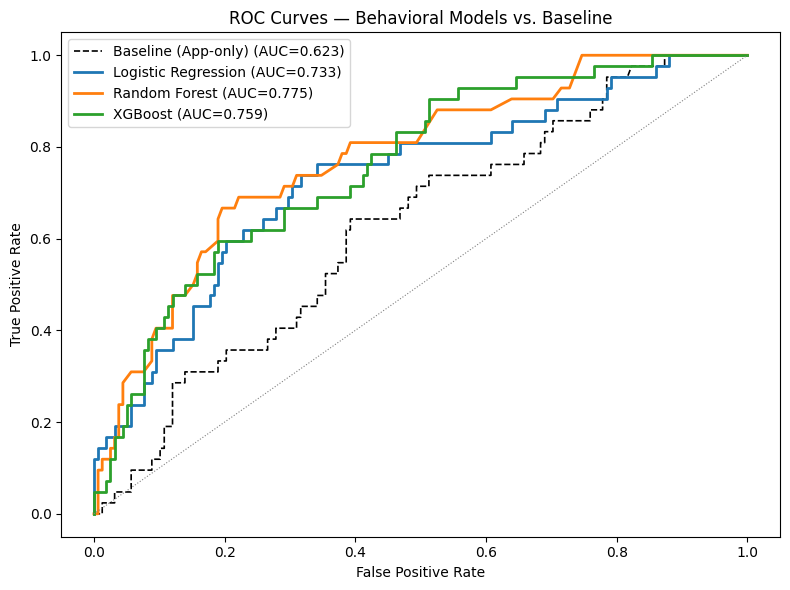

Saved ROC comparison plot.


In [13]:
results = {
    'Baseline (App-only)':  {'metrics': baseline_metrics, 'prob': baseline_prob},
    'Logistic Regression':  {'metrics': lr_metrics,       'prob': lr_prob},
    'Random Forest':        {'metrics': rf_metrics,       'prob': rf_prob},
    'XGBoost':              {'metrics': xgb_metrics,      'prob': xgb_prob},
}

df_cmp = pd.DataFrame({k: v['metrics'] for k, v in results.items()}).T
df_cmp = df_cmp.sort_values('roc_auc', ascending=False)
display(df_cmp.style.highlight_max(color='#d4f1d4').format('{:.4f}'))

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, info in results.items():
    fpr, tpr, _ = roc_curve(y_test, info['prob'])
    ls    = '--' if 'Baseline' in name else '-'
    color = 'black' if 'Baseline' in name else None
    lw    = 1.2 if 'Baseline' in name else 2.0
    ax.plot(fpr, tpr, linestyle=ls, linewidth=lw, color=color,
            label=f"{name} (AUC={info['metrics']['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Behavioral Models vs. Baseline')
ax.legend()
fig.tight_layout()
plt.savefig(DATA_DIR / '05_behav_roc_comparison.png', dpi=150)
plt.show()
print('Saved ROC comparison plot.')


## 13. Hyperparameter Tuning on Best Model

In [14]:
best_name = df_cmp.index[0]
print(f'Best baseline model: {best_name}  (ROC-AUC={df_cmp.loc[best_name, "roc_auc"]:.4f})')
print('Tuning XGBoost and Random Forest via RandomizedSearchCV (3-fold CV)...')

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Tune XGBoost ---
xgb_search = RandomizedSearchCV(
    Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            verbosity=0,
        )),
    ]),
    param_distributions={
        'clf__n_estimators':     [100, 200, 400],
        'clf__max_depth':        [3, 5, 7],
        'clf__learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'clf__subsample':        [0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring='roc_auc', cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0,
)
xgb_search.fit(X_train, y_train)
print(f'XGBoost CV ROC-AUC: {xgb_search.best_score_:.4f}  params: {xgb_search.best_params_}')

# --- Tune Random Forest ---
rf_search = RandomizedSearchCV(
    Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(
            class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ]),
    param_distributions={
        'clf__n_estimators':     [100, 200, 400],
        'clf__max_depth':        [None, 10, 20, 30],
        'clf__max_features':     ['sqrt', 'log2'],
        'clf__min_samples_leaf': [1, 2, 5],
    },
    n_iter=20, scoring='roc_auc', cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0,
)
rf_search.fit(X_train, y_train)
print(f'Random Forest CV ROC-AUC: {rf_search.best_score_:.4f}  params: {rf_search.best_params_}')

if xgb_search.best_score_ >= rf_search.best_score_:
    search        = xgb_search
    tuned_label   = 'Tuned XGBoost'
else:
    search        = rf_search
    tuned_label   = 'Tuned Random Forest'

tuned_pipe = search.best_estimator_
print(f'\nBest tuned model: {tuned_label}  (CV ROC-AUC={search.best_score_:.4f})')

Best baseline model: Random Forest  (ROC-AUC=0.7751)
Tuning XGBoost and Random Forest via RandomizedSearchCV (3-fold CV)...


XGBoost CV ROC-AUC: 0.7436  params: {'clf__subsample': 0.7, 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 1.0}


Random Forest CV ROC-AUC: 0.7484  params: {'clf__n_estimators': 100, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': None}

Best tuned model: Tuned Random Forest  (CV ROC-AUC=0.7484)


In [15]:
tuned_prob = tuned_pipe.predict_proba(X_test)[:, 1]
tuned_pred = tuned_pipe.predict(X_test)

tuned_metrics = {
    'roc_auc':   round(roc_auc_score(y_test, tuned_prob), 4),
    'accuracy':  round(accuracy_score(y_test, tuned_pred), 4),
    'precision': round(precision_score(y_test, tuned_pred, zero_division=0), 4),
    'recall':    round(recall_score(y_test, tuned_pred, zero_division=0), 4),
    'f1':        round(f1_score(y_test, tuned_pred, zero_division=0), 4),
}

results[tuned_label] = {'metrics': tuned_metrics, 'prob': tuned_prob}

print(f'[{tuned_label}]  ROC-AUC={tuned_metrics["roc_auc"]:.4f}  F1={tuned_metrics["f1"]:.4f}')

df_cmp2 = pd.DataFrame({k: v['metrics'] for k, v in results.items()}).T
df_cmp2 = df_cmp2.sort_values('roc_auc', ascending=False)
display(df_cmp2.style.highlight_max(color='#d4f1d4').format('{:.4f}'))

[Tuned Random Forest]  ROC-AUC=0.7700  F1=0.4675


,roc_auc,accuracy,precision,recall,f1
Random Forest,0.7751,0.7950,0.5556,0.1190,0.1961
Tuned Random Forest,0.7700,0.7950,0.5143,0.4286,0.4675
XGBoost,0.7595,0.7900,0.5000,0.4762,0.4878
Logistic Regression,0.7328,0.6950,0.3827,0.7381,0.5041
Baseline (App-only),0.6233,0.6200,0.2703,0.4762,0.3448


## 14. Final Evaluation of Best Model

In [16]:
final_pipe  = tuned_pipe
final_label = tuned_label
final_name  = tuned_label.lower().replace(' ', '_')

print(classification_report(y_test, tuned_pred, target_names=['Adimplente (0)', 'Inadimplente (1)']))

                  precision    recall  f1-score   support

  Adimplente (0)       0.85      0.89      0.87       158
Inadimplente (1)       0.51      0.43      0.47        42

        accuracy                           0.80       200
       macro avg       0.68      0.66      0.67       200
    weighted avg       0.78      0.80      0.79       200



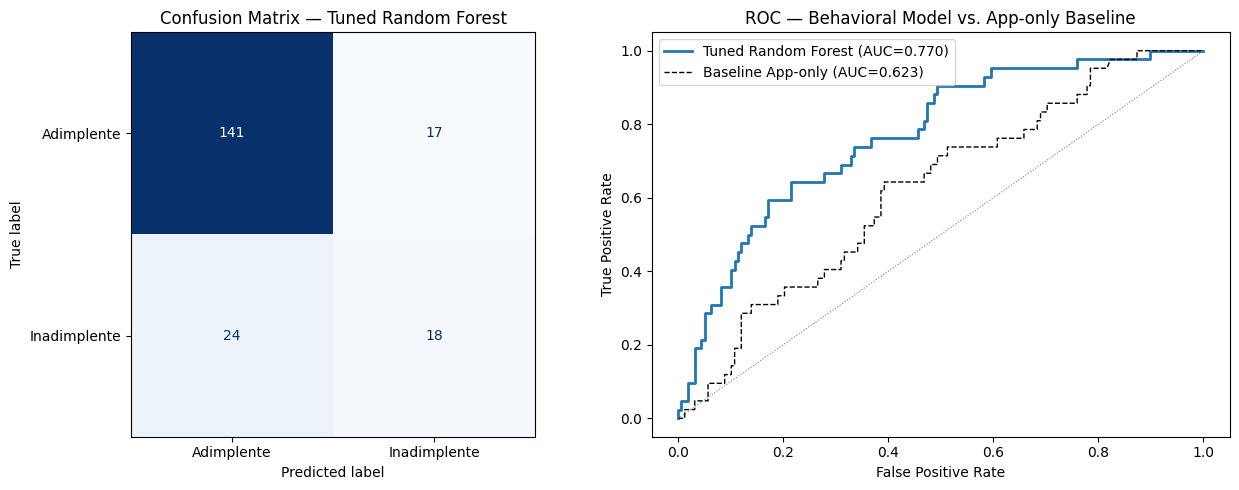

Saved final evaluation plot.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, tuned_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Adimplente', 'Inadimplente'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {final_label}')

# ROC curve (tuned vs. baseline)
fpr_t, tpr_t, _ = roc_curve(y_test, tuned_prob)
fpr_b, tpr_b, _ = roc_curve(y_test, baseline_prob)
axes[1].plot(fpr_t, tpr_t, label=f'{final_label} (AUC={tuned_metrics["roc_auc"]:.3f})', linewidth=2)
axes[1].plot(fpr_b, tpr_b, 'k--', label=f'Baseline App-only (AUC={baseline_metrics["roc_auc"]:.3f})', linewidth=1)
axes[1].plot([0, 1], [0, 1], 'gray', linewidth=0.8, linestyle=':')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC — Behavioral Model vs. App-only Baseline')
axes[1].legend()

fig.tight_layout()
plt.savefig(DATA_DIR / '05_behav_final_evaluation.png', dpi=150)
plt.show()
print('Saved final evaluation plot.')

## 15. Feature Importance — Behavioral vs. Application Signal

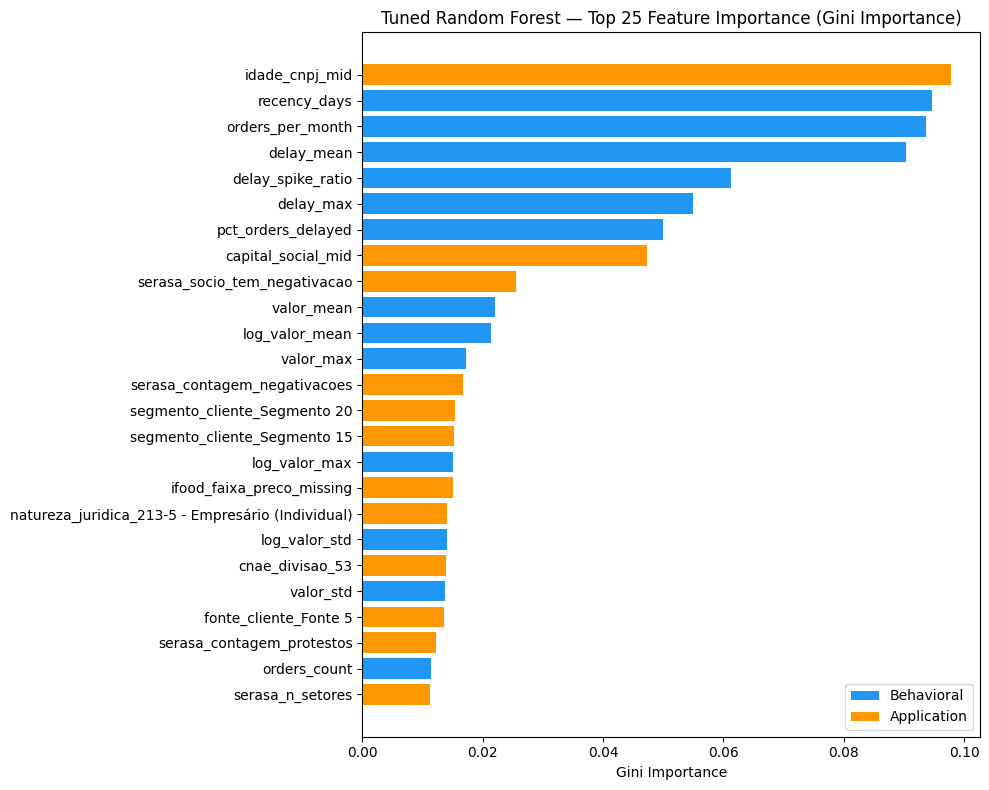


Top 15 features:
                     feature  importance        type
              idade_cnpj_mid    0.097759 Application
                recency_days    0.094679  Behavioral
            orders_per_month    0.093695  Behavioral
                  delay_mean    0.090297  Behavioral
           delay_spike_ratio    0.061256  Behavioral
                   delay_max    0.054932  Behavioral
          pct_orders_delayed    0.050026  Behavioral
          capital_social_mid    0.047359 Application
serasa_socio_tem_negativacao    0.025568 Application
                  valor_mean    0.022064  Behavioral
              log_valor_mean    0.021410  Behavioral
                   valor_max    0.017206  Behavioral
serasa_contagem_negativacoes    0.016798 Application
segmento_cliente_Segmento 20    0.015335 Application
segmento_cliente_Segmento 15    0.015252 Application

Importance by feature type:
               sum    mean  count
type                             
Application  0.412  0.0063     65
Beh

In [18]:
def get_feature_names(pipe):
    pre = pipe.named_steps['pre']
    names = []
    for tname, trans, cols in pre.transformers_:
        if tname == 'remainder' or trans == 'drop':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            names.extend(trans.get_feature_names_out(cols).tolist())
        else:
            names.extend(cols)
    return names


try:
    feat_names = get_feature_names(final_pipe)
    clf = final_pipe.named_steps['clf']

    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
        kind = 'Gini Importance'
    elif hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_[0])
        kind = '|Coefficient|'
    else:
        raise ValueError('Model does not expose feature importances.')

    fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)

    # Tag each feature as behavioral or application
    fi_df = fi.reset_index()
    fi_df.columns = ['feature', 'importance']
    fi_df['type'] = fi_df['feature'].apply(
        lambda f: 'Behavioral' if any(
            f.startswith(p) for p in [
                'orders_count', 'valor_', 'log_valor', 'delay_', 'pct_orders',
                'recency', 'orders_per_month', 'has_any_delay', 'delay_spike'
            ]
        ) else 'Application'
    )

    top_n = 25
    top_fi = fi_df.head(top_n)
    colors = top_fi['type'].map({'Behavioral': '#2196F3', 'Application': '#FF9800'})

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top_fi['feature'][::-1], top_fi['importance'][::-1], color=colors[::-1])
    ax.set_title(f'{final_label} — Top {top_n} Feature Importance ({kind})')
    ax.set_xlabel(kind)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2196F3', label='Behavioral'),
        Patch(facecolor='#FF9800', label='Application'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    fig.tight_layout()
    plt.savefig(DATA_DIR / '05_behav_feature_importance.png', dpi=150)
    plt.show()

    print(f'\nTop 15 features:')
    print(fi_df.head(15).to_string(index=False))

    # Summary by type
    print('\nImportance by feature type:')
    print(fi_df.groupby('type')['importance'].agg(['sum', 'mean', 'count']).round(4))

except Exception as e:
    print(f'Feature importance unavailable: {e}')

## 16. Behavioral Feature Deep-Dive

Visualise how the key behavioral signals relate to default.

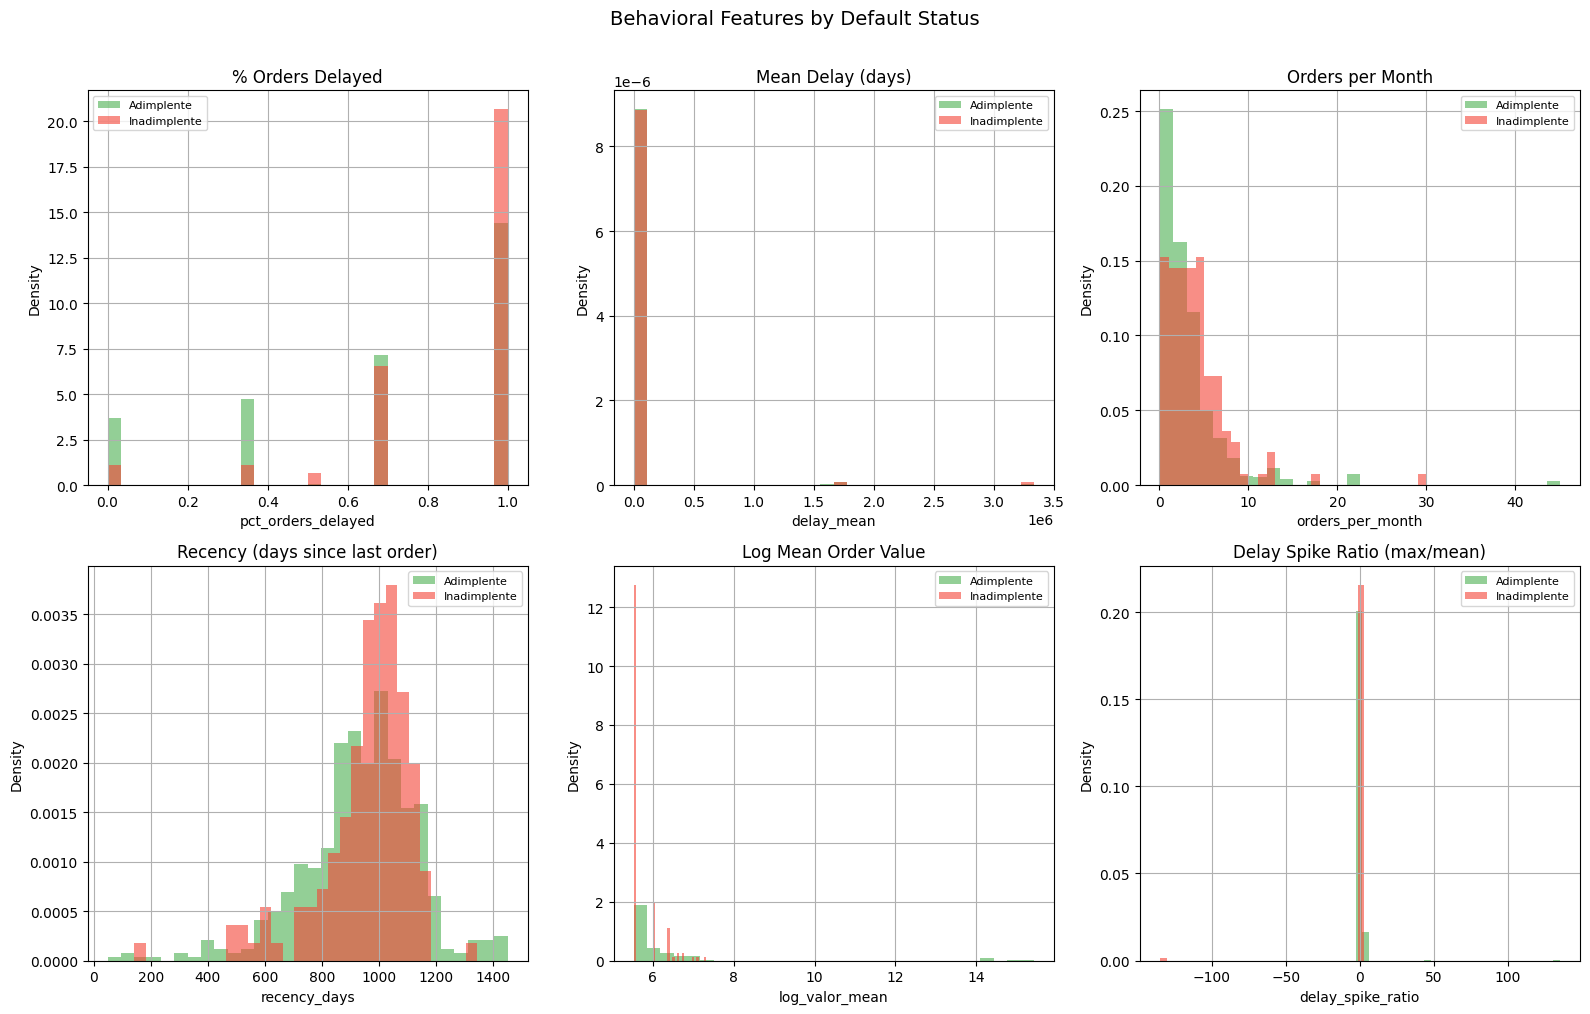

Saved behavioral feature distribution plot.


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_specs = [
    ('pct_orders_delayed',  '% Orders Delayed'),
    ('delay_mean',          'Mean Delay (days)'),
    ('orders_per_month',    'Orders per Month'),
    ('recency_days',        'Recency (days since last order)'),
    ('log_valor_mean',      'Log Mean Order Value'),
    ('delay_spike_ratio',   'Delay Spike Ratio (max/mean)'),
]

for ax, (col, label) in zip(axes, plot_specs):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    for target_val, color, name in [(0, '#4CAF50', 'Adimplente'), (1, '#F44336', 'Inadimplente')]:
        subset = df[df['inadimplente'] == target_val][col].dropna()
        subset.hist(ax=ax, bins=30, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Behavioral Features by Default Status', fontsize=14, y=1.01)
fig.tight_layout()
plt.savefig(DATA_DIR / '05_behav_feature_distributions.png', dpi=150)
plt.show()
print('Saved behavioral feature distribution plot.')

## 17. Save Best Model & Metrics

In [20]:
ts           = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path   = MODELS_DIR / f'05_behavioral_best_{final_name}_{ts}.joblib'
metrics_path = MODELS_DIR / f'05_behavioral_metrics_{ts}.json'

joblib.dump(final_pipe, model_path)
print(f'Model saved → {model_path.name}')

all_metrics = {name: info['metrics'] for name, info in results.items()}
all_metrics['_best']        = final_name
all_metrics['_best_params'] = search.best_params_
all_metrics['_n_samples']   = len(df_raw)
all_metrics['_behavioral_features'] = behavioral_feature_names
all_metrics['_lift_vs_app_only'] = round(
    tuned_metrics['roc_auc'] - baseline_metrics['roc_auc'], 4
)

with open(metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=2, default=str)
print(f'Metrics saved → {metrics_path.name}')

lift = all_metrics['_lift_vs_app_only']
print(f'\nROC-AUC lift from behavioral features: {lift:+.4f}')
if lift > 0:
    print('✓ Behavioral features improve prediction over application-only baseline.')
else:
    print('⚠ No improvement over application-only baseline on this subset.')

Model saved → 05_behavioral_best_tuned_random_forest_20260614_105248.joblib
Metrics saved → 05_behavioral_metrics_20260614_105248.json

ROC-AUC lift from behavioral features: +0.1467
✓ Behavioral features improve prediction over application-only baseline.


## 18. Prediction Function

In [21]:
def predict_behavioral_risk(model_path: str, df_new: pd.DataFrame) -> pd.Series:
    """
    Load the behavioral model and return default probability per client.
    df_new must include both application and behavioral features.
    Returns a Series of probabilities in [0, 1].
    """
    pipe = joblib.load(model_path)
    return pd.Series(pipe.predict_proba(df_new)[:, 1], index=df_new.index, name='default_prob')


# Demo: score 5 clients from the test set
sample = X_test.head(5)
scores = predict_behavioral_risk(str(model_path), sample)
demo_df = sample[['orders_count', 'pct_orders_delayed', 'delay_mean', 'recency_days']].assign(
    default_prob=scores,
    true_label=y_test.head(5).values,
    risk_tier=pd.cut(scores, bins=[0, 0.15, 0.30, 1.0],
                     labels=['Low (<15%)', 'Medium (15-30%)', 'High (>30%)'])
)
print('Sample predictions:')
display(demo_df)

Sample predictions:


,orders_count,pct_orders_delayed,delay_mean,recency_days,default_prob,true_label,risk_tier
132,3.0,1.000000,1.666667,849.0,0.374694,0,High (>30%)
481,3.0,0.000000,-50.000000,639.0,0.132719,0,Low (<15%)
611,3.0,0.666667,-13.666667,1176.0,0.532350,0,High (>30%)
320,2.0,0.500000,-24.500000,957.0,0.511175,1,High (>30%)
325,3.0,0.666667,-16.000000,1094.0,0.121324,0,Low (<15%)


## Summary

| Step | Result |
|------|--------|
| Sub-population | Clients with ≥1 order (664 of 3,000) |
| Default rate | ~20.8% (lower than full portfolio at 31.3%) |
| Behavioral features | orders_count, valor stats, delay stats, recency, orders_per_month + log/binary/ratio derivations |
| Split | 70% train · 30% test (stratified) |
| Baseline (App-only on same subset) | See metrics above |
| Best behavioral model | Selected by ROC-AUC via RandomizedSearchCV |
| Lift vs. app-only | See `_lift_vs_app_only` in saved metrics |

**Next → Phase 6:** Model Router — build `data_richness_score` and `complexity_score` to
dynamically dispatch clients to the Application Model or Behavioral Model.